# Clase 8 - Aprendizaje Supervisado

## Notebook 2: Regresión Logística

Alumno: Sara Valenzuela  
Materia: Minería de Datos  

En este notebook se aplica un modelo de Regresión Logística utilizando el dataset Titanic. El objetivo es predecir si un pasajero sobrevivió o no a partir de las variables edad, tarifa del boleto y sexo.

In [89]:
# Cargar Librerias
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [90]:
## Carga del dataset Titanic
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [91]:
## Exploración inicial del dataset
print("Dimensiones del dataset:", df.shape)
df.info()

Dimensiones del dataset: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [92]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Limpieza y transformación de datos

In [93]:
df = df.dropna(subset=["age", "fare", "sex", "survived"])

df["sex"] = df["sex"].map({"male": 1, "female": 0})

df[["age", "fare", "sex", "survived"]].head()

,age,fare,sex,survived
0,22.0,7.2500,1,0
1,38.0,71.2833,0,1
2,26.0,7.9250,0,1
3,35.0,53.1000,0,1
4,35.0,8.0500,1,0


## Visualización exploratoria

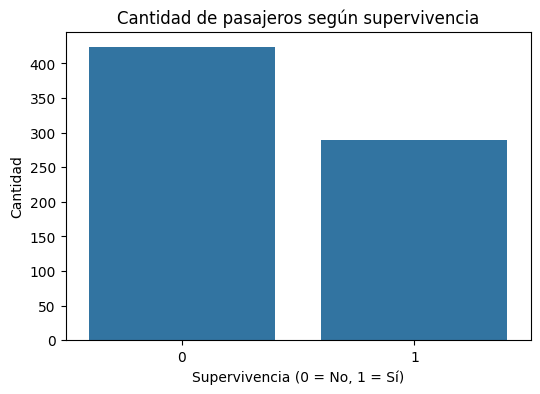

In [94]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")

plt.title("Cantidad de pasajeros según supervivencia")
plt.xlabel("Supervivencia (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")

plt.show()

Interpretación:

Se observa que la cantidad de pasajeros que no sobrevivieron es superior a la cantidad de pasajeros sobrevivientes. Esto indica una ligera desproporción entre las clases que debe considerarse al evaluar el modelo.

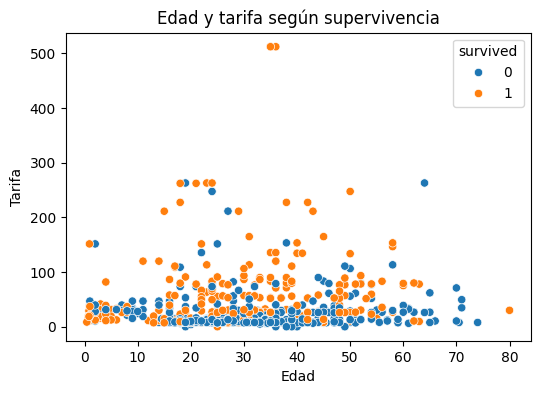

In [95]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="age", y="fare", hue="survived")

plt.title("Edad y tarifa según supervivencia")
plt.xlabel("Edad")
plt.ylabel("Tarifa")

plt.show()

Interpretación:

La relación entre edad y tarifa presenta una alta dispersión. No se observa una separación clara entre las clases únicamente utilizando estas variables, lo que justifica la utilización de un modelo de aprendizaje supervisado para encontrar patrones más complejos.

## Preparación de variables

In [96]:
X = df[["age", "fare", "sex"]]
y = df["survived"]

X.head()

,age,fare,sex
0,22.0,7.2500,1
1,38.0,71.2833,0
2,26.0,7.9250,0
3,35.0,53.1000,0
4,35.0,8.0500,1


## División en entrenamiento y prueba

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (571, 3)
Datos de prueba: (143, 3)


## Entrenamiento del modelo de Regresión Logística

In [98]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Predicciones y evaluación del modelo

In [99]:
y_pred = model.predict(X_test)

precision = accuracy_score(y_test, y_pred)

print("Precisión:", round(precision, 2))

Precisión: 0.75


In [100]:
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[69 18]
 [18 38]]


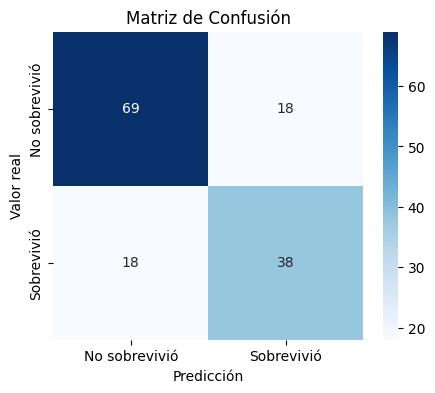

In [101]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No sobrevivió", "Sobrevivió"],
    yticklabels=["No sobrevivió", "Sobrevivió"]
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [102]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        87
           1       0.68      0.68      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143



## Interpretación de resultados

La Regresión Logística permite predecir una variable categórica binaria. En este caso, la variable objetivo es `survived`, donde 0 representa que el pasajero no sobrevivió y 1 representa que sí sobrevivió.

La precisión obtenida indica qué proporción de predicciones fueron correctas sobre el conjunto de prueba.

La matriz de confusión permite observar los aciertos y errores del modelo, diferenciando entre pasajeros correctamente clasificados como sobrevivientes o no sobrevivientes y aquellos que fueron clasificados de manera incorrecta.

## Conclusión

En este notebook se aplicó un modelo de Regresión Logística para predecir la supervivencia de los pasajeros del Titanic utilizando las variables edad, tarifa del boleto y sexo.

El modelo permitió resolver un problema de clasificación binaria, ya que la variable objetivo solo puede tomar dos valores posibles: sobrevivió o no sobrevivió. Además, la matriz de confusión y el reporte de clasificación permitieron evaluar el desempeño del modelo de manera más completa.

Se concluye que la Regresión Logística es una herramienta adecuada para problemas donde se busca predecir categorías, especialmente cuando la variable objetivo representa dos clases posibles.